In [1]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecMonitor

### Add mbt-gym to path

In [2]:
import sys
sys.path.append("../")

In [3]:
from mbt_gym.agents.BaselineAgents import CarteaJaimungalMmAgent
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.StableBaselinesTradingEnvironment import StableBaselinesTradingEnvironment
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.wrappers import *
from mbt_gym.rewards.RewardFunctions import PnL, CjMmCriterion
from mbt_gym.stochastic_processes.midprice_models import BrownianMotionMidpriceModel
from mbt_gym.stochastic_processes.arrival_models import PoissonArrivalModel
from mbt_gym.stochastic_processes.fill_probability_models import ExponentialFillFunction
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics

### Create market making environment

In [4]:
import sys
sys.path.append("../") # This version of the notebook is in the subfolder "notebooks" of the repo

import gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import quad

from copy import deepcopy


from mbt_gym.agents.BaselineAgents import *
from mbt_gym.gym.TradingEnvironment import TradingEnvironment
from mbt_gym.gym.helpers.generate_trajectory import generate_trajectory
from mbt_gym.gym.helpers.plotting import *
from mbt_gym.stochastic_processes.midprice_models import *
from mbt_gym.stochastic_processes.arrival_models import *
from mbt_gym.stochastic_processes.fill_probability_models import *
import torch
#print(torch.cuda.is_available())
#print(torch.cuda.get_device_name())
from mbt_gym.gym.ModelDynamics import LimitOrderModelDynamics
seed = 53


In [5]:
from mbt_gym.stochastic_processes.midprice_models import ArithmeticBrownianMotionWithFadsMidpriceModel

### Parameters

In [ ]:
initial_price = 100
terminal_time = 1.0
sigma = 1.0
n_steps = 1000
initial_inventory = 0
fads_proportion = 0.6 # p is defined directly inside the ArithmeticBrownianMotionWithFadsMidpriceModel class as sqrt(1-q^2)
eta = 10
baseline_arrival_rate = np.array([[5.0, 5.0]])
phi = 15
k = 1
fill_exponent = 0
gamma = k
alpha=0.001
mu=0
big_phi = 0.1

In [19]:
# OU parameters
u0 = 0.0
xi = 1.0

def m(t):
    return u0 * np.exp(-eta * t)

def v(t):
    return (xi**2) / (2.0 * eta) * (1.0 - np.exp(-2.0 * eta * t))

def compute_psi(q):
    c = gamma * sigma * q
    def integrand(t):
        return np.exp(c * m(t) + 0.5 * (c**2) * v(t))
    denom, _ = quad(integrand, 0.0, terminal_time)
    return (30.0 - phi * terminal_time) / denom

# compute psi for each fad proportion
psi = compute_psi(fads_proportion)

print("psi value:", psi)
# intensity =  np.array([psi + phi, psi + phi])  # intensity for PoissonArrivalModel

psi value: 14.872283180889763


In [20]:
def get_as_env(num_trajectories:int = 1):
    midprice_model = ArithmeticBrownianMotionWithFadsMidpriceModel(initial_price=initial_price,
                                                 volatility=sigma, fads_proportion=fads_proportion, eta=eta, step_size=terminal_time/n_steps,
                                                 terminal_time=terminal_time,
                                                 num_trajectories=num_trajectories)
    arrival_model = FadsInformedUniformedTradersArrivalModel(baseline_arrival_rate=baseline_arrival_rate,
                                                step_size=terminal_time/n_steps,
                                                phi=phi,
                                                psi=psi,
                                                k=k,
                                                gamma=gamma,
                                                fads_proportion=fads_proportion,
                                                sigma=sigma)
    fill_probability_model = ExponentialFillFunction(fill_exponent=fill_exponent, 
                                                     step_size=1/n_steps,
                                                     num_trajectories=num_trajectories)
    LOtrader = LimitOrderModelDynamics(midprice_model = midprice_model, arrival_model = arrival_model, 
                                fill_probability_model = fill_probability_model,
                                num_trajectories = num_trajectories)
    reward = CjMmCriterion(per_step_inventory_aversion = big_phi,
                           terminal_inventory_aversion = alpha,
                           terminal_time = terminal_time)
    env_params = dict(terminal_time=terminal_time, 
                      n_steps=n_steps,
                      seed = seed,
                      initial_inventory = initial_inventory,
                      model_dynamics = LOtrader,
                      reward_function = reward,
                      max_inventory=n_steps,
                      normalise_action_space = False,
                      normalise_observation_space = False,
                      num_trajectories=num_trajectories)
    return TradingEnvironment(**env_params)

In [21]:
as_env = get_as_env()

In [22]:
as_agent = MMwithFadsInformedUniformedTradersAgent(env=as_env)
print(as_env.model_dynamics
      .midprice_model)


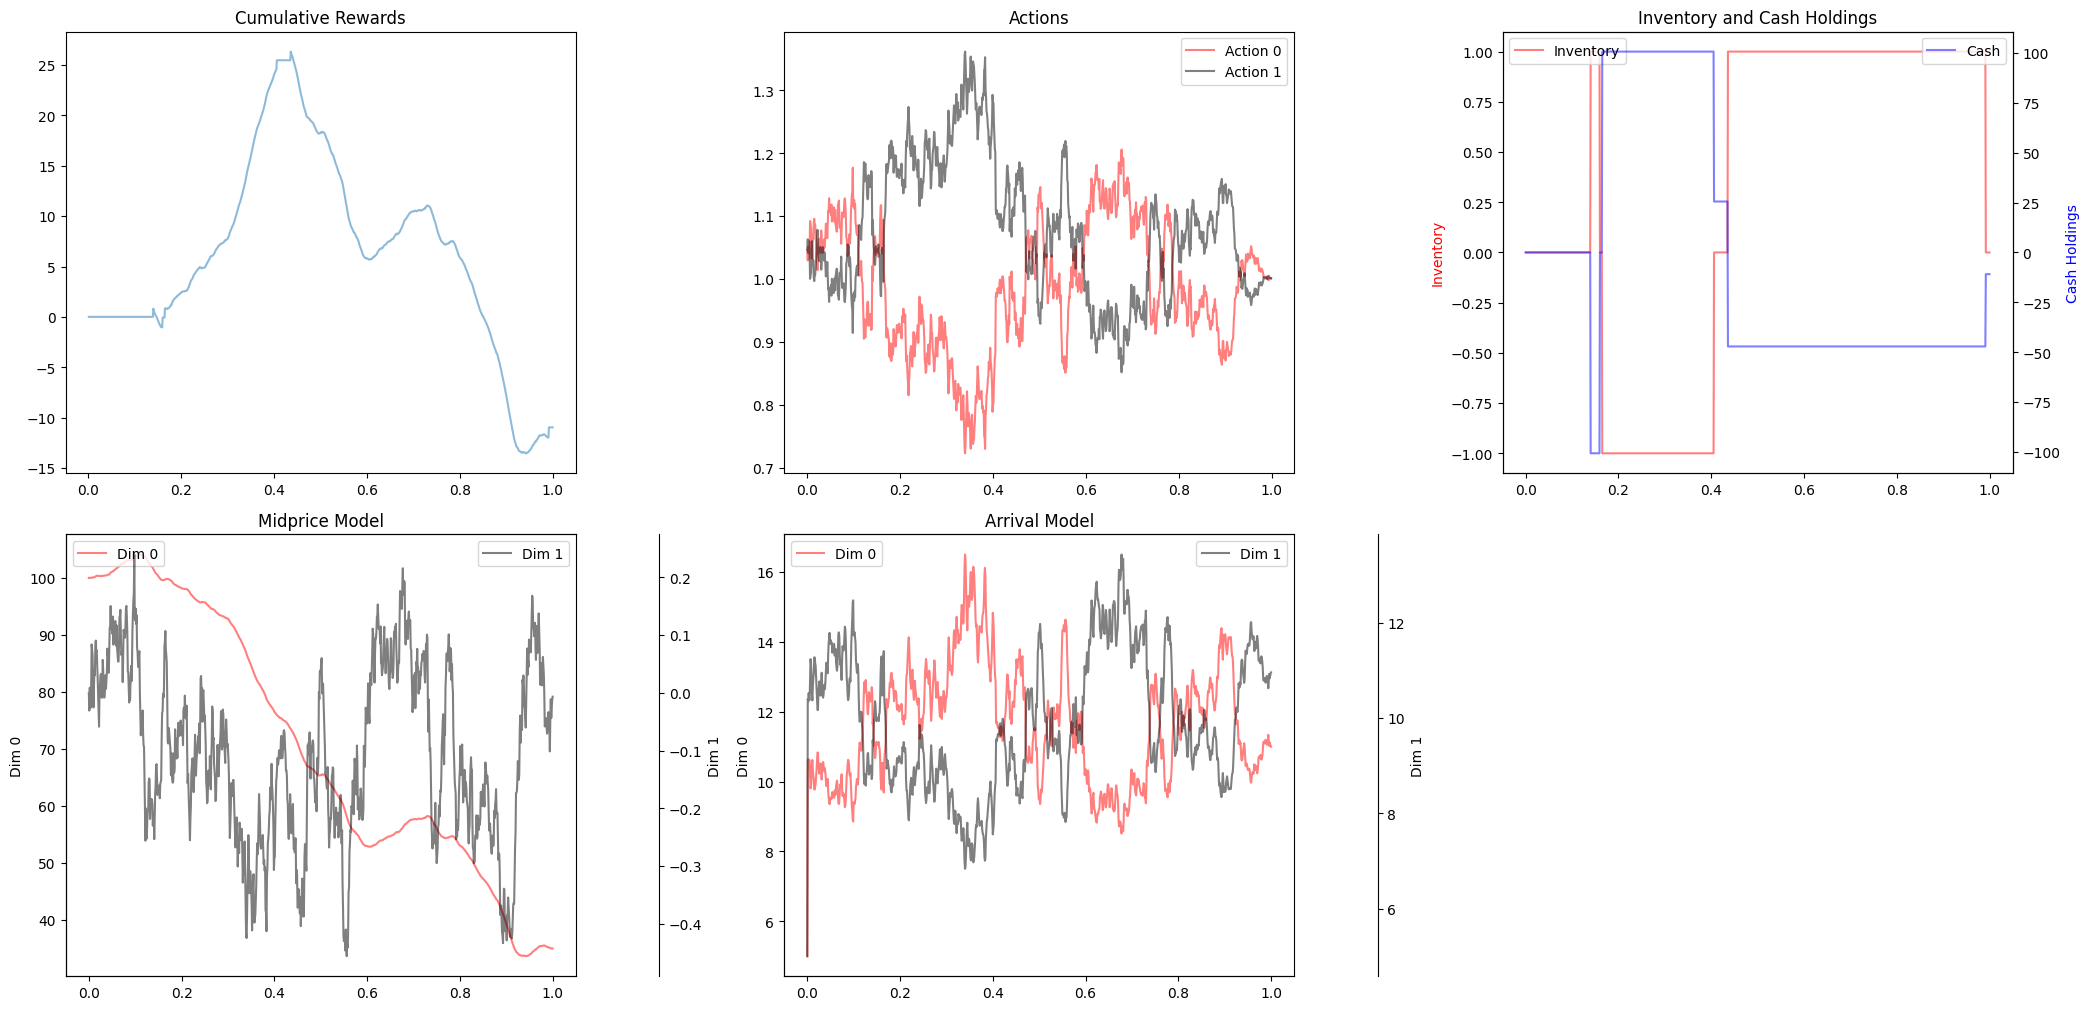

In [23]:
plot_trajectory_extended(as_env, as_agent)

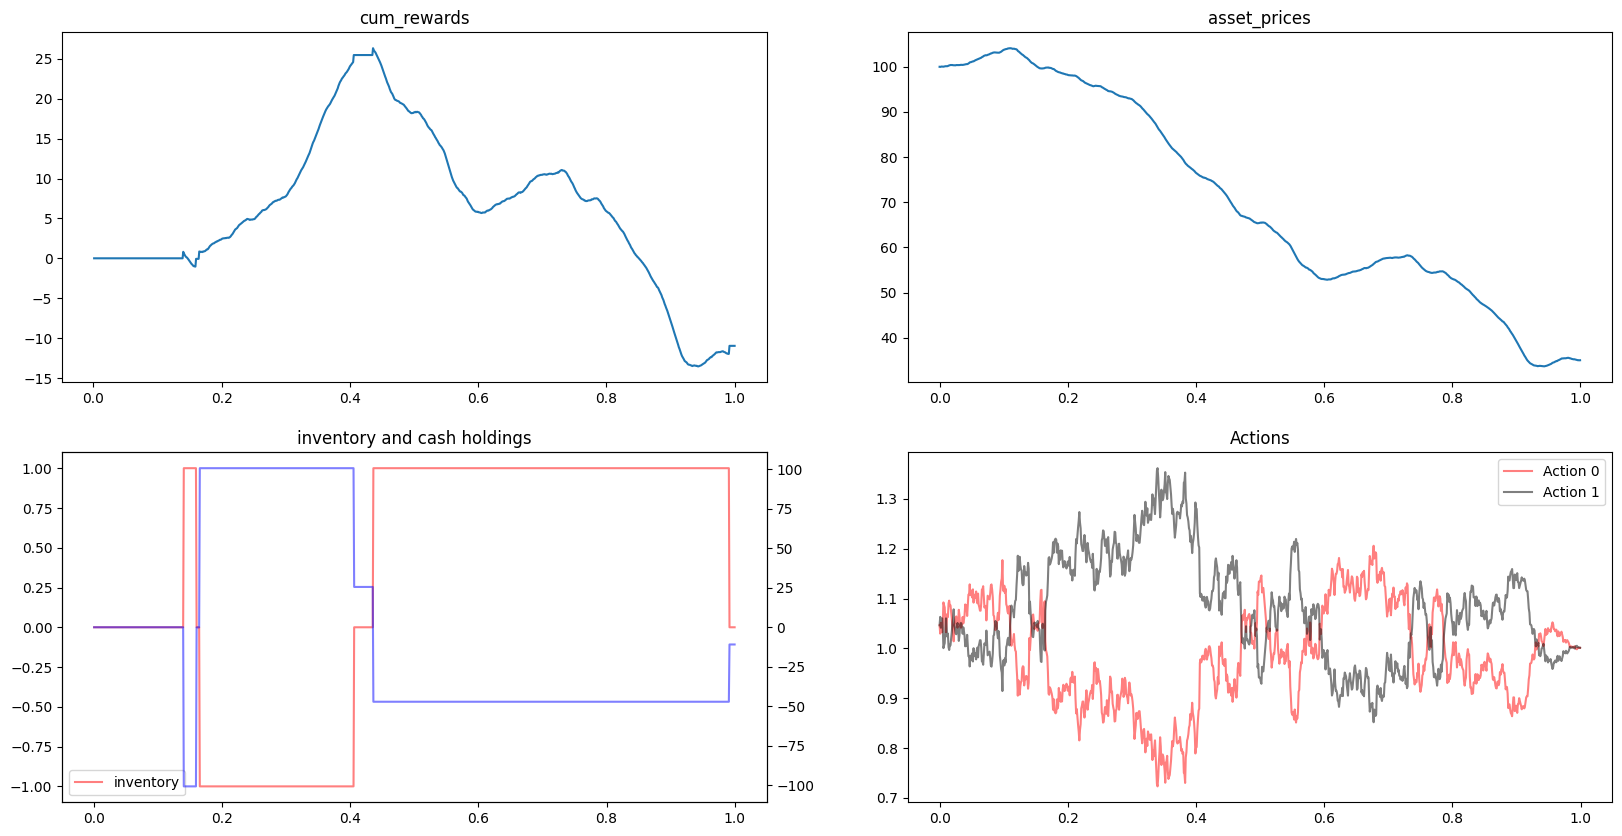

In [24]:
plot_trajectory(as_env, as_agent, seed = seed)

In [25]:
num_trajectories = 1000
vec_env = get_as_env(num_trajectories)
vec_as = MMwithFadsInformedUniformedTradersAgent(env=vec_env)

print(vec_env.model_dynamics
      .midprice_model)

In [26]:
observations, actions, rewards = generate_trajectory(vec_env, vec_as)

In [27]:
results, fig, total_rewards = generate_results_table_and_hist(vec_env=vec_env,agent=vec_as)

In [28]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065499,-19.754058,88.689885,0.024,2.188475


In [29]:
exact without sqrt

SyntaxError: invalid syntax (591303711.py, line 1)

In [ ]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065499,-19.456059,130.39275,0.006,3.403228


In [ ]:
exact with sqrt

SyntaxError: invalid syntax (2062222917.py, line 1)

In [ ]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065499,21.499659,6.3401,0.02,3.155567


In [ ]:
Euler-Maruyama discretization of the OU process

SyntaxError: invalid syntax (1686216076.py, line 1)

In [ ]:
results

,Mean spread,Mean PnL,Std PnL,Mean terminal inventory,Std terminal inventory
Inventory,2.065499,21.498253,6.339149,0.019,3.156682


Euler empirical variance: 0.05254
Exact OU empirical variance: 0.04991
Theoretical variance: 0.05000


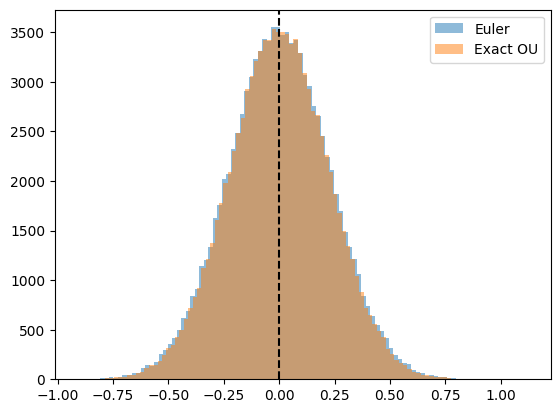

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# OU parameters
eta = 10.0
dt = 0.01
T = 1.0
num_steps = int(T / dt)
num_paths = 100_000  # simulate many paths for accurate variance

# Initialize
X_euler = np.zeros((num_paths, num_steps+1))
X_exact = np.zeros((num_paths, num_steps+1))

# Random increments
rng = np.random.default_rng(42)
dB = rng.normal(size=(num_paths, num_steps))

# --- Euler-Maruyama ---
for i in range(num_steps):
    X_euler[:, i+1] = X_euler[:, i] - eta * X_euler[:, i] * dt + np.sqrt(dt) * dB[:, i]

# --- Exact OU ---
exp_term = np.exp(-eta * dt)
std_term = np.sqrt((1 - np.exp(-2 * eta * dt)) / (2 * eta))
for i in range(num_steps):
    X_exact[:, i+1] = X_exact[:, i] * exp_term + std_term * dB[:, i]

# Compute empirical variance at final time
var_euler = np.var(X_euler[:, -1])
var_exact = np.var(X_exact[:, -1])

# Theoretical variance
var_theory = (1 - np.exp(-2 * eta * T)) / (2 * eta)

print(f"Euler empirical variance: {var_euler:.5f}")
print(f"Exact OU empirical variance: {var_exact:.5f}")
print(f"Theoretical variance: {var_theory:.5f}")

# Optional: plot distributions
plt.hist(X_euler[:, -1], bins=100, alpha=0.5, label='Euler')
plt.hist(X_exact[:, -1], bins=100, alpha=0.5, label='Exact OU')
plt.axvline(0, color='k', linestyle='--')
plt.legend()
plt.show()
